<a href="https://colab.research.google.com/github/cccano/sprint7-final-project/blob/main/Proyect_Telecom_S7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sn
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código


In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


En el dataset no se evidencia que las columnas tengan un tipo de dato incorrecto, las columnas que tienen texto son tipo object, las númericas con valores enteros son int64 y las columnas con valores decimales son tipo float.

In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users

print('Cantidad de valores nulos')
print(users.isna().sum().sort_values(ascending = False))
print()
print('Proporción de valores nulos')
print(users.isna().mean().sort_values(ascending = False)*100)


Cantidad de valores nulos
churn_date    3534
city           469
user_id          0
first_name       0
last_name        0
age              0
reg_date         0
plan             0
dtype: int64

Proporción de valores nulos
churn_date    88.350
city          11.725
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
reg_date       0.000
plan           0.000
dtype: float64


En el dataset de users se evidencia que la columna city tiene 469 valores nulos, que supone el 12% de los datos de la columna, las columnas rag_date y churn_date son tipo object en vez de datetime. Ademas la columna churn_date tiene 3534 valores nulos lo cual supone el 88% de los datos de la columna.

Hay que descartar que los valores nulos de la columna churn_date sean por un error, o en el mejor de los casos sea asociado a los usuarios que no se han dado de baja de algunos de los planes.

In [ ]:
# cantidad de nulos para usage
print('Cantidad de valores nulos')
print(usage.isna().sum().sort_values(ascending = False))
print()
print('Proporción de valores nulos')
print(usage.isna().mean().sort_values(ascending = False)*100)

Cantidad de valores nulos
duration    22076
length      17896
date           50
id              0
user_id         0
type            0
dtype: int64

Proporción de valores nulos
duration    55.190
length      44.740
date         0.125
id           0.000
user_id      0.000
type         0.000
dtype: float64


En el dataset usage se encontro que la columna date es tipo object en vez de datetime. En las columnas date,duration y length hay valores nulos con un porcentaje de 0.125%, 55% y 45% respectivamente. La columna length es tipo float pero puede ser tipo int64, ya que la longitud del mensaje siempre se da como un número entero.

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

     las columnas:churn_date    88 %,
                 city          11.7 %,
                 duration    55.190 %,
                 length      44.740 %,
                 date         0.125 %.
  
- Indica qué harías: ¿imputar, eliminar, ignorar?

columna churn_date obtaria por crear una variable sintetica "is_churn", 1 si churn_date y 0 si es nulo, ya que pueden ser usuarios fieles a la compañia y no se han dado de baja.

La columna city se imputaran con la palabra "desconocido" para tratar como una catergoría y que no pierda valor estas filas.

Las columnas duration y length se pueden imputar y reemplazar con la media o mediana del mismo usuario o plan ya que componen significatiamente parte importante de los datos.

La columna date se pueden eliminar los nulos ya que no comprende parte significativamente de los datos, o evaluar si hay secuencialidad en las fechas por usuario y plan para imputar por arrastre.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users[['user_id','age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.

*La media y mediana son iguales lo que sugiere que tiene uns distribución no sesgada y que los datos se distribuyen alredoder de estos dos valores,la desvianción estándar no es muy grande respecto a los valores que se manejan de ID para los usarios, así que no se ve una alta dispersión.*

- La columna `age` ...

*Se obaerva un valor minimo de -999 lo cual indica un error que puede afectar el valor de la media y altera la variabilidad de los datos haciendo los mas dispersos.
la meda < mediana lo que indica que los datos están sesgados hacia la izquierda.*
  

In [ ]:
# explorar columnas numéricas de usage
usage[['id','user_id']].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

*'id': es una columna secuencia para enumerar cada registro del 1 al 40000 y por ende su media y mediana son similares y no se observan sentinels.
  'user_id': es una columna con el id propio de cada usuario, tiene una media un poco similares lo cual indica que puede tener una distribución casi normal y no se observan sentinels*

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()



,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [ ]:
users['city'].value_counts(dropna = False)

Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [ ]:
users['plan'].value_counts()

Basico     2595
Premium    1405
Name: plan, dtype: int64

- La columna `city` ...

*Se encontro un valor sentinel (?) con 96 registros, ádemas hay que estandarizar los nombres de las ciudades.*
  
- La columna `plan` ...
  
*En la columna 'plan' no se encotraron sentienels y los nombres de los planes tienen un estándar.*

In [ ]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

In [ ]:
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` ...
  
-*No se hayaron sentinels y las categorias tienen un estándar*

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
 **¿En qué columnas encontraste valores inválidos o sentinels?**
- *En las columnas 'age' y 'city' se hayaron los siguientes sentinels (-999, ?) respectivamente.*
  
 **¿Qué acción tomarías?**
- *con la columna 'age' reemplazaria los valores (-999) con mediana.*
- *con la columna 'city' reemplazaria los valores (?) con 'Desconocido'.*

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce') # completa el código
print(users['reg_date'].dtype)

datetime64[ns]


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce')# completa el código
print(usage['date'].dtype)

datetime64[ns]


In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts(dropna = False))

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

*Se observa que aparecen años como 2022,2023 y 2026, y solo deben haber datos hasta el 2024, así que los registros del 2026 se pueden eliminar ya que no son muchos datos, filtrar la columna para ignorar estos en el análisis o convertirlos a NA.*

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts(dropna = False))

2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

-*Se observa que solo hay datos del 2024 lo cual indica solo activadad en ese año y algunos valores ausentes.*

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
**¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)**

- *Si en la columna 'reg_date' aparece el año 2026 y solo debemos tener datos hasta el 2024.*
  
**¿Qué harías con ellas?**

-*se puede filtrar la columna para obtener los datos del periodo de 2022 a 2024 o eliminar los registros del 2026 Yya que no son varios registros, pero se convertiran a NA.*

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].value_counts(dropna = False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'] > pd.Timestamp('2024-12-31'),'reg_date'] = pd.NaT
# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna = False))

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
print('valores nulos:', usage['duration'].isna().sum())
print('proporción:', usage['duration'].isna().mean()*100)
print()
print('verificando relación con la columna type')
usage['duration'].isna().groupby(usage['type']).mean()*100


valores nulos: 22076
proporción: 55.19

verificando relación con la columna type


type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print('valores nulos:', usage['length'].isna().sum())
print('proporción:', usage['length'].isna().mean()*100)
print()
print('verificando relación con la columna type')
usage['length'].isna().groupby(usage['type']).mean()*100


valores nulos: 17896
proporción: 44.74

verificando relación con la columna type


type
call    99.932991
text     0.000000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

*Los valores nulos de la columna 'duration' se deben a un comportamiento normal del negocio, ya que los mensajes de texto no generan tiempo de duración, lo mismo pasa para la columna 'length' las llamadas no generan longitud de caracteres así que estos valores nulos son correctos respecto a este comportamiento de la información.*

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    text_count = ('is_text','sum'),
    call_count = ('is_call','sum'),
    total_call_duration = ('duration','sum')
).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,text_count,call_count,total_call_duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns ={'text_count':'cant_mensajes',
                             'call_count':'cant_llamadas',
                             'total_call_duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg,on = 'user_id',how = 'left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
cols_numericas = user_profile.select_dtypes(include='number').columns.tolist()

def resumen (df,columnas):
    resultados = []
    for col in columnas:
        datos = {
            'columna':col,
            'media':df[col].mean(),
            'medina':df[col].median(),
            'des_estádar':df[col].std(),
            'minimo':df[col].min(),
            'máximo':df[col].max(),
            'nulos':df[col].isna().sum(),
            'por_nulos':df[col].isna().mean()*100
        }
        resultados.append(datos)
    return pd.DataFrame(resultados).set_index('columna').T

resumen(user_profile,cols_numericas)


columna,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
media,11999.500000,48.122250,5.524381,4.478120,23.317054
medina,11999.500000,47.000000,5.000000,4.000000,19.780000
des_estádar,1154.844867,17.690408,2.358416,2.144238,18.168095
minimo,10000.000000,18.000000,0.000000,0.000000,0.000000
máximo,13999.000000,79.000000,17.000000,15.000000,155.690000
nulos,0.000000,0.000000,1.000000,1.000000,1.000000
por_nulos,0.000000,0.000000,0.025000,0.025000,0.025000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize = True, dropna = False)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

In [ ]:
user_profile.shape

(4000, 11)

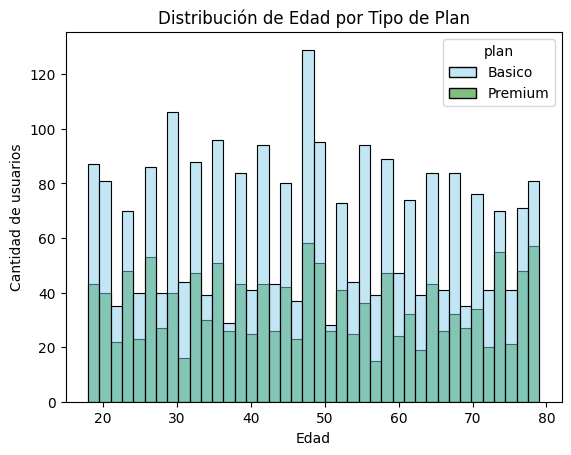

In [ ]:
# Histograma para visualizar la edad (age)
import seaborn as sns

sns.histplot(user_profile,x = 'age',
             hue='plan',
             bins = 40,
             palette=['skyblue','green'])
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights:
-**Distribución ...**

- *No hay una gran diferencia en la desición de optar por un plan básico o premium respecto a la edad.*

- *Es muy notalbe que sin importar la edad el plan básico tiene mas preferencia ya sea por lo economico de este.*

- *Entre los 48 y 50 años hay una mayoria que prefiere el plan básico, pero no es muy significante el número de usuarios para considerarlo como nicho.*

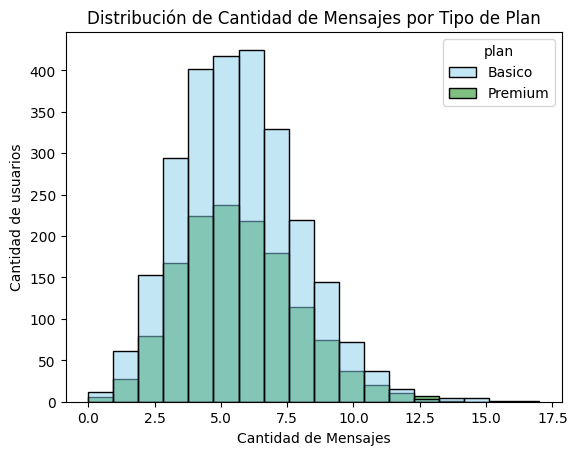

In [ ]:
# Histograma para visualizar la cant_mensajes

sns.histplot(user_profile,x = 'cant_mensajes',
             hue='plan',
             bins = 18,
             palette=['skyblue','green'])
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights:
- *Se observa que en el plan básico como el premium se suele enviar igual cantidad de mensajes y se percibe una concentración de varios usuarios que envian entre 5 y 7 mensajes.*
- *No se observa una ventaja significativa en tener un plan premium respecto a uso de mensajes de texto.*

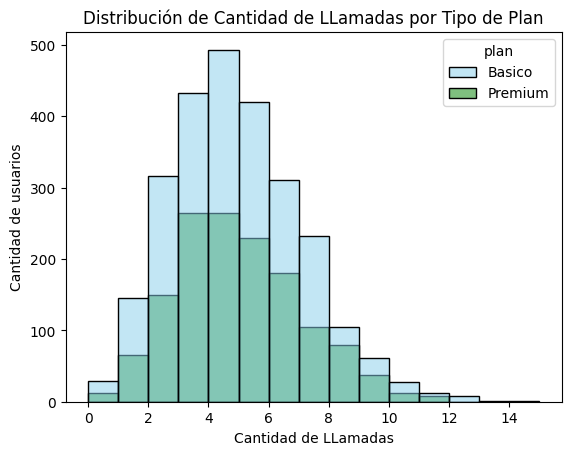

In [ ]:
# Histograma para visualizar la cant_llamadas

sns.histplot(user_profile,x = 'cant_llamadas',
             hue='plan',
             bins = 15,
             palette=['skyblue','green'])
plt.title('Distribución de Cantidad de LLamadas por Tipo de Plan')
plt.xlabel('Cantidad de LLamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights:
- **Distribución**
- *Se observa una distribución muy simetrica casi normal, la gran mayoria de los usuarios realizan entre 2 y 7 llamadas, no se ve una diferencia entre uso de planes, lo cual indica que no hay una gran ventaja para el usuario de plan premium.*

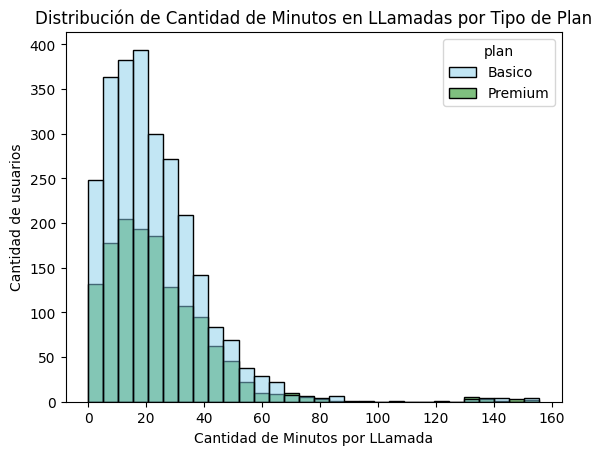

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile,x = 'cant_minutos_llamada',
             hue='plan',
             bins = 30,
             palette=['skyblue','green'])
plt.title('Distribución de Cantidad de Minutos en LLamadas por Tipo de Plan')
plt.xlabel('Cantidad de Minutos por LLamada')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- *Hay una distribución muy sesgada a la derecha, lo cual indica que los usuarios indiferente del plan que usen tienden hacer llamadas de 0 a 25 minutos.*
- *hay un muy pequeña cantidad de usuarios que realizan llamdas de mas de 100 minutos.*
- *No se observa una ventaja significativa para usuarios de plan premium en llamadas.*

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

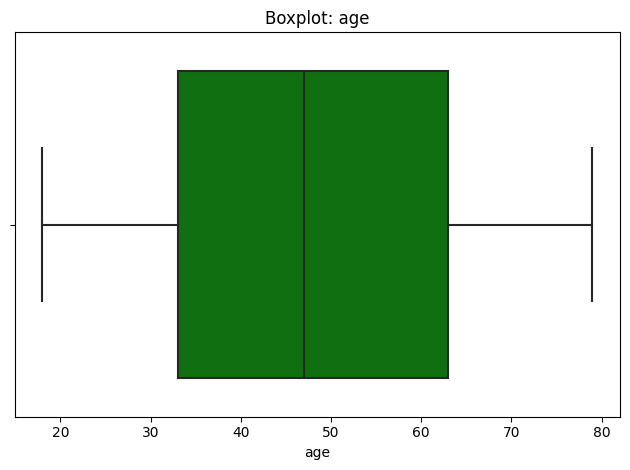

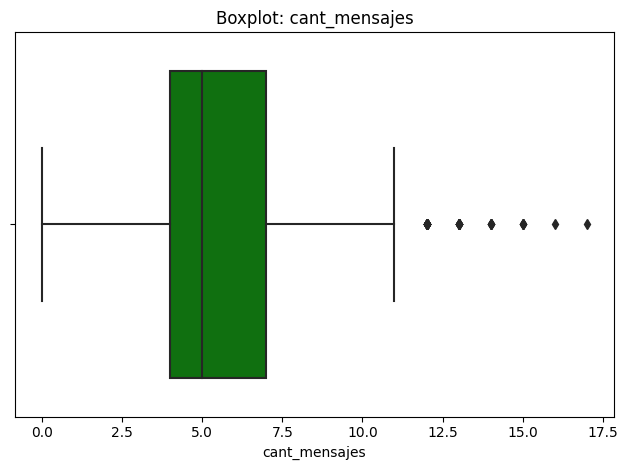

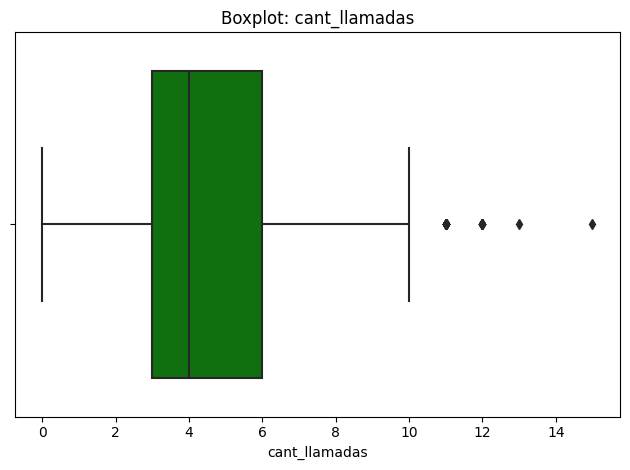

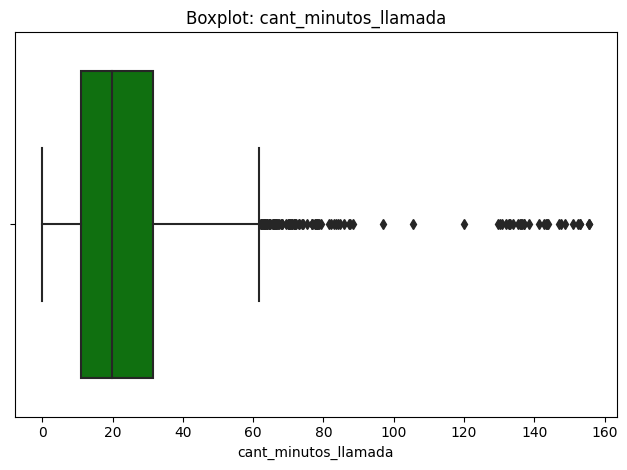

In [ ]:
# Visualizando usando BoxPlot

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data = user_profile, x=col, color = 'green')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()



💡Insights:
- Age: ...(presenta o no outliers)
 *La columna age no presenta outliers.*
- cant_mensajes:
 *presenta outliers a partir de valores mayores a 11 en cantidad de mensajes*
- cant_llamadas:
 *presenta outliers a partir de valores mayores a 10 en cantidad de llamadas.*
- cant_minutos_llamada:
 *presenta outliers a partir de valores mayores a 60 minutos en llamadas.*

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

def limites_upper(df, columnas):
    lista = []

    for col in columnas:
        # 1. Calcular cuartiles e IQR usando puntos decimales
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        upper_limit = q3 + (1.5 * iqr)

        # 2. Guardar métricas en el diccionario
        datos = {
            'columna': col,
            'Q1': q1,
            'Q3': q3,
            'IQR': iqr,
            'upper_limit': upper_limit
        }

        lista.append(datos)

    return pd.DataFrame(lista)

# Ejecución
limites_upper(user_profile, columnas_limites)



,columna,Q1,Q3,IQR,upper_limit
0,cant_mensajes,4.00,7.000,3.000,11.5000
1,cant_llamadas,3.00,6.000,3.000,10.5000
2,cant_minutos_llamada,11.12,31.415,20.295,61.8575


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?
  
- *Son datos reales y plausibles que los usuarios, ya que realizar un número de 17 mensajes, 15 llamadas y 155 minutos de duración se debe al comportamiento particular de algunos usuarios que pueden representar un segmento de valor*

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso


def clasify_segment(row):
    llamada = row['cant_llamadas']
    mensaje = row['cant_mensajes']

    if pd.isna(llamada) or pd.isna(mensaje):
        return 'error'

    if llamada < 5 and mensaje < 5:
        return 'Bajo uso'

    elif llamada < 10 and mensaje < 10:
        return 'Uso medio'

    else:
        return 'Alto uso'



user_profile['grupo_uso'] = user_profile.apply(clasify_segment, axis = 1)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasify_age(row):
    edad = row['age']

    if pd.isna(edad):
        return 'error'

    if edad < 30:
        return 'Joven'

    elif edad < 60:
        return 'Adulto'

    else:
        return 'Adulto Mayor'



user_profile['grupo_edad'] = user_profile.apply(clasify_age, axis = 1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

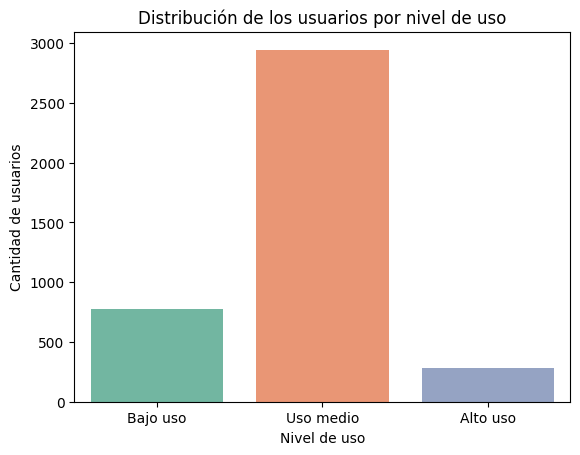

In [ ]:
# Visualización de los segmentos por uso
import seaborn as sns

sns.countplot(data = user_profile,
             x = 'grupo_uso',
             order=['Bajo uso', 'Uso medio', 'Alto uso'],
             palette = 'Set2')
plt.title('Distribución de los usuarios por nivel de uso')
plt.ylabel('Cantidad de usuarios')
plt.xlabel('Nivel de uso')
plt.show()


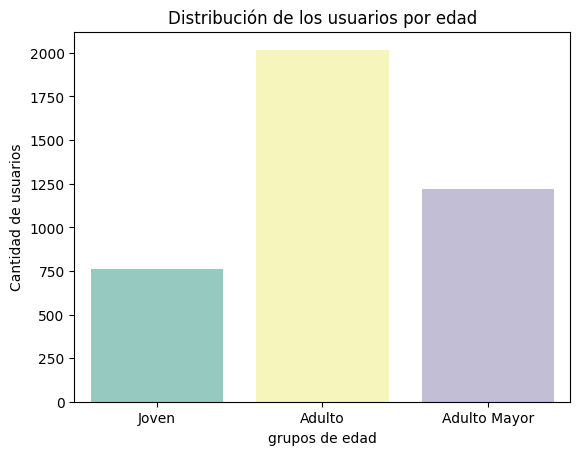

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data = user_profile,
             x = 'grupo_edad',
             order=['Joven', 'Adulto', 'Adulto Mayor'],
             palette = 'Set3')
plt.title('Distribución de los usuarios por edad')
plt.ylabel('Cantidad de usuarios')
plt.xlabel('grupos de edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
  
  *En el dataset de users se evidencia que la columna city tiene 469 valores nulos, que supone el 12% de los datos de la columna, las columnas rag_date y churn_date son tipo object en vez de datetime. Ademas la columna churn_date tiene 3534 valores nulos lo cual supone el 88% de los datos de la columna, pero estos son atribuidos a que siguen siendo usuarios que aún no han dado de baja el plan de telefonia así que no se debe a un error.*

  *En el dataset usage se encontro que la columna date es tipo object en vez de datetime. En las columnas date,duration y length con valores nulos en porcentaje de 0.125%, 55% y 45% respectivamente.*

  
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

   *Se identificaron dimensiones de segmentación de los clientes por edad (Joven, Adulto y Adulto Mayor) y nivel de uso (Bajo uso, Uso medio y Alto uso).*

  *El comportamiento por edad destaca que el grupo de adultos entre los 30 y 60 años, siendo el grupo mas grande con 2000 usuarios, seguido de los adultos mayores con mas de 1000.*

  *El comportamiento por nivel de uso destaca el grupo de uso medio que son los usuarios que realizan entre 5 y 10 llamadas y mensajes con 3000 usuarios.*

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

  *Deacuerdo a la numero de usuarios de los segmentos, los mas valiosos son los usuarios con un uso medio y que sen adultos entre 30 y 60, ya que estan en una etapa activa laboral requieren hacer uso frecuente del plan de llamadas y mensajes en el día a día.*
  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

  *hay usuarios que realizan entre 10 y 17 mensajes, entre 10 y 15 llamadas y entre 60 y 155 minutos de duración en llamadas. estos datos son bastante posibles entre los usuarios así que se puede ver como un nicho el cual requiere un servicio diferencial respecto a los planes Básico y Premium.*

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

  *Crear un plan llamado 'Unlimited' para usuarios que realizan llamadas con mas de 60 minutos de duración*

  *Identificar se el grupo de 'Adultos' son mas orientados a un plan expecifico ya que pueden ser apropopiados para campañas de 'upgrade/upselling'.*

  *Rediseñar los planes de telefonia ya que no hay una gran diferencia entre los usuarios que hace uso del plan básico respecto a los usuarios premium, se podría mejorar el premium con incentivos diferenciadores como bolsas de datos mas amplios.*

 *Las campañas deben enfocarse mas en los niveles de uso de los usuarios y no en las edades ya que la edad no determina la elección del plan telefonico.*  

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

En el dataset de users se evidencia que la columna city tiene 469 valores nulos, que supone el 12% de los datos de la columna, las columnas rag_date y churn_date son tipo object en vez de datetime. Ademas la columna churn_date tiene 3534 valores nulos lo cual supone el 88% de los datos de la columna, pero estos son atribuidos a que siguen siendo usuarios que aún no han dado de baja el plan de telefonia así que no se debe a un error.

En el dataset usage se encontro que la columna date es tipo object en vez de datetime. En las columnas date,duration y length con valores nulos en porcentaje de 0.125%, 55% y 45% respectivamente.


🔍 **Segmentos por Edad**

Se identificaron dimensiones de segmentación de los clientes por edad (Joven, Adulto y Adulto Mayor).

El comportamiento por edad destaca que el grupo de adultos entre los 30 y 60 años, siendo el grupo mas grande con 2000 usuarios, seguido de los adultos mayores con mas de 1000.


📊 **Segmentos por Nivel de Uso**

Segemntación por nivel de uso (Bajo uso, Uso medio y Alto uso).

El comportamiento por nivel de uso destaca el grupo de uso medio que son los usuarios que realizan entre 5 y 10 llamadas y mensajes con 3000 usuarios.

➡️ Esto sugiere que ...

Deacuerdo a la numero de usuarios de los segmentos, los mas valiosos son los usuarios con un uso medio y que sean adultos entre 30 y 60, ya que estan en una etapa activa laboral requieren hacer uso frecuente del plan de llamadas y mensajes en el día a día.

💡 **Recomendaciones**

Crear un plan llamado 'Unlimited' para usuarios que realizan llamadas con mas de 60 minutos de duración

Identificar se el grupo de 'Adultos' son mas orientados a un plan expecifico ya que pueden ser apropopiados para campañas de 'upgrade/upselling'.

Rediseñar los planes de telefonia ya que no hay una gran diferencia entre los usuarios que hace uso del plan básico respecto a los usuarios premium, se podría mejorar el premium con incentivos diferenciadores como bolsas de datos mas amplios.

Las campañas deben enfocarse mas en los niveles de uso de los usuarios y no en las edades ya que la edad no determina la elección del plan telefonico.




---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

- https://github.com/cccano/sprint7-final-project